In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [11]:
# Load the data we processed in Task 1
# Ensure this file exists in data/processed/
df = pd.read_csv('../data/processed/cleaned_prices.csv', index_col='Date', parse_dates=True)

In [12]:
# Select TSLA
tsla_data = df['TSLA']

# Split Train (2015-2024) and Test (2025-2026)
train_data = tsla_data[:'2024-12-31']
test_data = tsla_data['2025-01-01':]

print(f"Train Shape: {train_data.shape}, Test Shape: {test_data.shape}")

Train Shape: (2516,), Test Shape: (259,)


Training samples: 2516
Test samples: 259
Training ARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=0.83 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.14 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.162 seconds

ARIMA RMSE: 82.93
ARIMA MAE: 69.50


d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


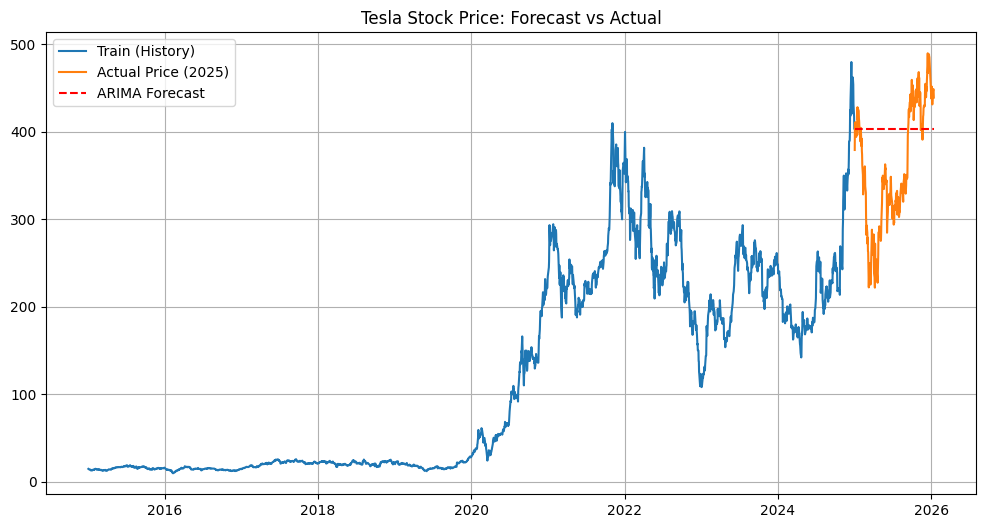

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

# --- RE-LOAD DATA TO ENSURE FRESH START ---
df = pd.read_csv('../data/processed/cleaned_prices.csv', index_col='Date', parse_dates=True)
tsla_data = df['TSLA']
train_data = tsla_data[:'2024-12-31']
test_data = tsla_data['2025-01-01':]

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

# --- TRAINING ---
print("Training ARIMA...")
model_arima = auto_arima(train_data, seasonal=False, trace=True, error_action='ignore')

# --- FORECASTING (THE FIX) ---
# 1. Generate predictions
forecast_raw = model_arima.predict(n_periods=len(test_data))

# 2. Convert to a Series using the Test Data's index explicitly
# list(forecast_raw) ensures we don't accidentally try to match an integer index
forecast_series = pd.Series(list(forecast_raw), index=test_data.index)

# --- EVALUATION ---
# 3. Create comparison dataframe
comparison_df = pd.DataFrame({'Actual': test_data, 'Forecast': forecast_series})

# 4. Drop NaNs (Just in case dates don't perfectly align)
comparison_df = comparison_df.dropna()

# Check if data is empty before calculating
if len(comparison_df) == 0:
    print("ERROR: Comparison DataFrame is empty. Check your dates!")
else:
    rmse_arima = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['Forecast']))
    mae_arima = mean_absolute_error(comparison_df['Actual'], comparison_df['Forecast'])

    print(f"\nARIMA RMSE: {rmse_arima:.2f}")
    print(f"ARIMA MAE: {mae_arima:.2f}")

    # --- PLOTTING ---
    plt.figure(figsize=(12,6))
    plt.plot(train_data.index, train_data, label='Train (History)')
    plt.plot(test_data.index, test_data, label='Actual Price (2025)')
    plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='red', linestyle='--')
    plt.title('Tesla Stock Price: Forecast vs Actual')
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
# 1. Scale Data (LSTMs need data between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(tsla_data.values.reshape(-1, 1))

# 2. Helper to create sequences
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, 0])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

SEQ_LENGTH = 60
train_len = len(train_data)

# Prepare Train and Test Scaled Data
train_scaled = scaled_data[:train_len]
# We need the last 60 days of train data to predict the first day of test data
test_scaled = scaled_data[train_len - SEQ_LENGTH:] 

X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)

# Reshape for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 3. Build Model
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm.add(LSTM(50, return_sequences=False))
model_lstm.add(Dense(25))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(X_train, y_train, batch_size=32, epochs=5, verbose=1)

# 4. Predict
predictions = model_lstm.predict(X_test)
predictions = scaler.inverse_transform(predictions) # Scale back to dollars

# 5. Evaluate (Using the same fix strategy, though less likely to crash here)
rmse_lstm = np.sqrt(mean_squared_error(test_data, predictions))
print(f"LSTM RMSE: {rmse_lstm:.2f}")

Epoch 1/5


d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0052
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.8438e-04
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.6478e-04
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.8425e-04
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 6.3640e-04
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
LSTM RMSE: 25.10


In [16]:
# Train on ALL data to predict the future
full_model = auto_arima(tsla_data, seasonal=False)

# Forecast 6 months (approx 126 trading days)
future_steps = 126 
future_forecast = full_model.predict(n_periods=future_steps)

final_predicted_price = future_forecast.iloc[-1] # Get the last predicted price
current_price = tsla_data.iloc[-1] # Get the last known price

# Calculate Expected Return
expected_return_tsla = (final_predicted_price - current_price) / current_price
# Annualize it
annualized_return_tsla = expected_return_tsla * (252 / future_steps)

print("-" * 30)
print(f"Current Price: ${current_price:.2f}")
print(f"Forecast Price (6mo): ${final_predicted_price:.2f}")
print(f"Annualized Expected Return (TSLA): {annualized_return_tsla:.4f}")
print("-" * 30)
print("COPY THE RETURN VALUE ABOVE FOR THE NEXT NOTEBOOK")

------------------------------
Current Price: $439.20
Forecast Price (6mo): $439.45
Annualized Expected Return (TSLA): 0.0011
------------------------------
COPY THE RETURN VALUE ABOVE FOR THE NEXT NOTEBOOK


d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
